In [9]:
library("xgboost")
library("Matrix")
library("SHAPforxgboost")
library("data.table")
library("here")
library("ggplot2")
library("rsm")
library(Hmisc)
library(corrplot)
library(ClassDiscovery)
library(PMCMRplus)
library(rstatix)

Warning message:
"package 'rstatix' was built under R version 4.2.3"

Attaching package: 'rstatix'


The following object is masked from 'package:stats':

    filter




In [10]:
###########if packages are not installed yet, please use 'install.packages(package name)' to install packages.

######################################
#########################Variation analysis
#####################################

In [11]:
#########Mann-Whintey U test
Variationtest<- read.csv(file="d://增量预测//Utest.csv") ###use Utest.csv (data of Figure 5D) for example
wilcox.test(Variationtest[,1], Variationtest[,2])


	Wilcoxon rank sum exact test

data:  Variationtest[, 1] and Variationtest[, 2]
W = 65, p-value = 0.0001361
alternative hypothesis: true location shift is not equal to 0


In [12]:
#########Pair-wise Kruskal-Wallis test
multiVariationtest<- read.csv(file="d://增量预测//Kruskal-Wallis-test.csv") ###use Kruskal-Wallis-test.csv (data of Figure 6I) for example
pairwise_wilcox_test (multiVariationtest, Bioconversionrate ~ Group, p.adjust.method = "bonf")  ####p value adjusted by bonferroni post-hoc test ne4

,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,Bioconversionrate,Group A,Group B,10,10,0,1.08e-05,3.24e-05,****
2,Bioconversionrate,Group A,Group C,10,10,0,1.08e-05,3.24e-05,****
3,Bioconversionrate,Group B,Group C,10,10,71,1.23e-01,3.69e-01,ns


In [ ]:
######################################
#########################Correlation analysis
#####################################

,C,N,Vb,Vc,Fat,cellulose,Weightgain
C,1.000000000,0.02444373,-0.011065896,-0.002476059,-0.001448766,-0.58354573,-0.2367708
N,0.024443732,1.00000000,-0.110829409,0.069151824,0.032909162,-0.77901377,0.5686451
Vb,-0.011065896,-0.11082941,1.000000000,-0.007874806,-0.014610300,0.10874203,-0.1492845
Vc,-0.002476059,0.06915182,-0.007874806,1.000000000,0.023548972,-0.03544117,-0.1031420
Fat,-0.001448766,0.03290916,-0.014610300,0.023548972,1.000000000,0.04531338,-0.1141808
cellulose,-0.583545729,-0.77901377,0.108742027,-0.035441174,0.045313379,1.00000000,-0.2626112
Weightgain,-0.236770787,0.56864506,-0.149284451,-0.103142044,-0.114180761,-0.26261124,1.0000000


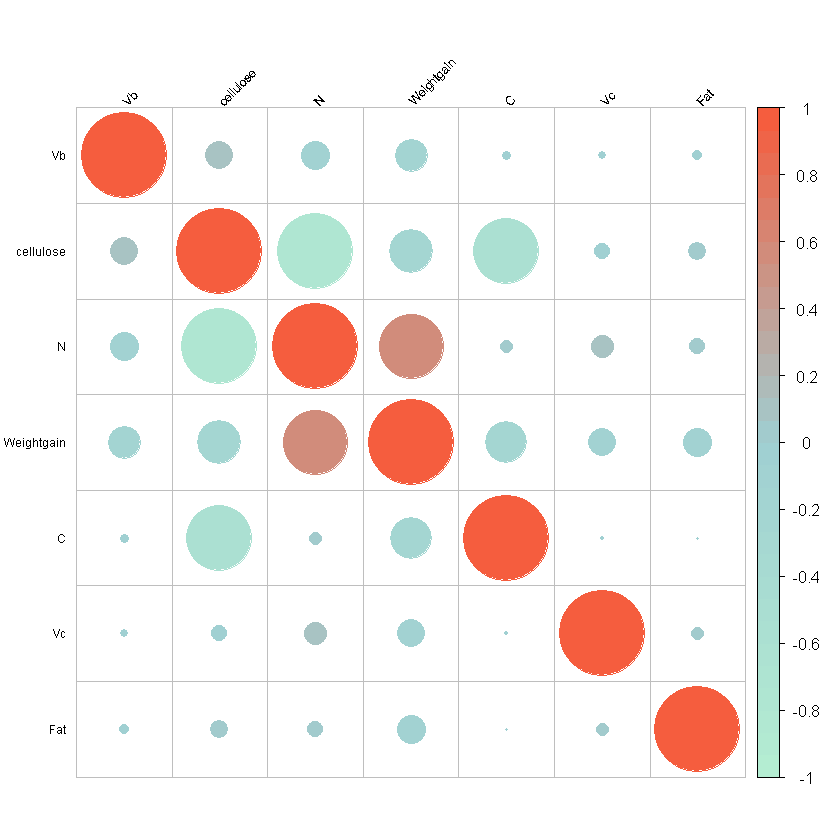

In [15]:
data<- read.csv(file="d://增量预测//增量数据rm.csv")       ###load weight gain data set
mdata<-cor(data,method="spearman")                 #####calculate the pearson correlation matrix
matrix<-as.matrix(mdata)
matrix
n<-30                   #####number of colors used in the heatmap
mycolors <- colorRampPalette(c("#B4EDD2", "#A0CFD3","#F55D3E"))(n)
corrplot(mdata,col=mycolors,method="circle", type="full", order="hclust", tl.col="black", tl.srt=45,rect.col="white",tl.cex=0.6,is.corr=)

In [ ]:
######################################
#########################Reponse surface analysis and correlated figures
#####################################

Warning message in predict.lm(lmobj, newdata = newdata):
"prediction from a rank-deficient fit may be misleading"
Near-stationary-ridge situation detected -- stationary point altered
 Change 'threshold' if this is not what you intend




Call:
rsm(formula = z ~ SO(x, y), data = data)

               Estimate  Std. Error t value  Pr(>|t|)    
(Intercept)  6.1498e-02  1.3067e-02  4.7062 8.671e-06 ***
x            2.3011e-03  7.1136e-04  3.2347  0.001681 ** 
y            4.3017e-04  1.6901e-03  0.2545  0.799650    
x^2         -2.0303e-05  1.1667e-05 -1.7402  0.085100 .  
y^2         -1.1052e-04  5.1924e-05 -2.1285  0.035907 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Multiple R-squared:  0.4083,	Adjusted R-squared:  0.3831 
F-statistic: 16.21 on 4 and 94 DF,  p-value: 3.931e-10

Analysis of Variance Table

Response: z
            Df   Sum Sq  Mean Sq F value    Pr(>F)
FO(x, y)     2 0.076235 0.038118 28.6642 1.909e-10
PQ(x, y)     2 0.010015 0.005008  3.7657   0.02672
Residuals   94 0.125001 0.001330                  
Lack of fit  3 0.079685 0.026562 53.3383 < 2.2e-16
Pure error  91 0.045316 0.000498                  

Stationary point of response surface:
       x        y 
0.000000 1.946075

Warning message in predict.lm(lmobj, newdata = newdata):
"prediction from a rank-deficient fit may be misleading"


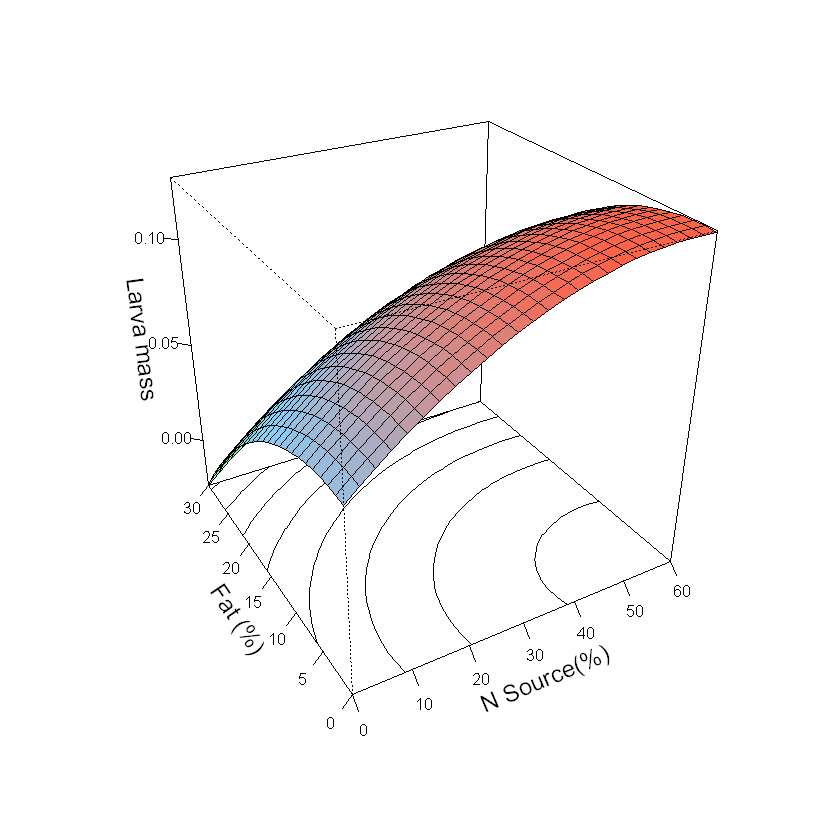

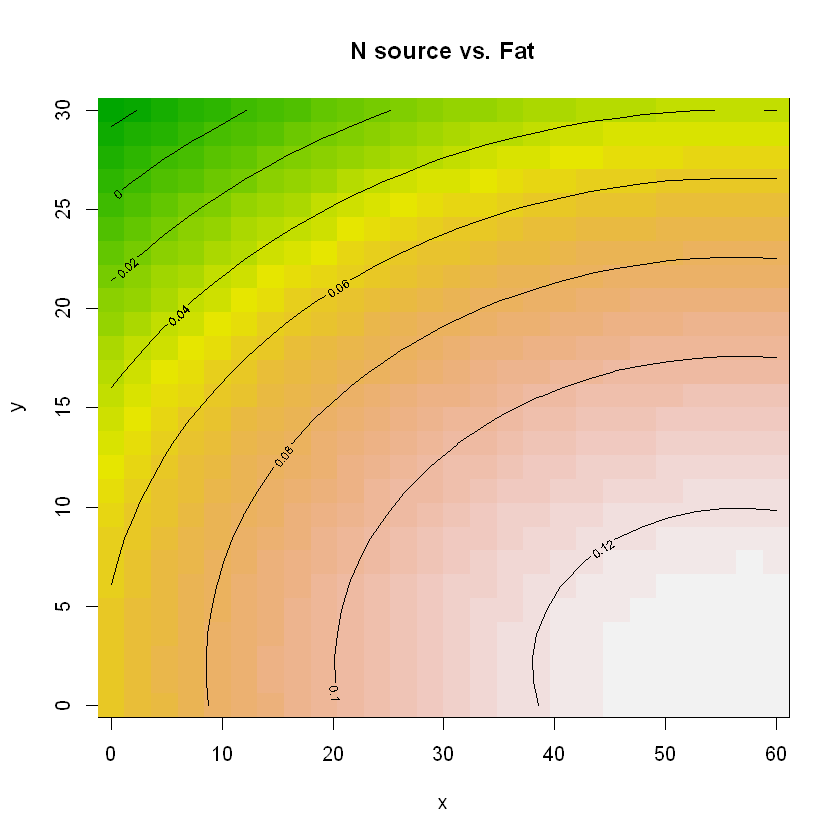

In [16]:
#####Response surface between protein and Fat content
 ###column x: protein(N)content; column y: Fat content; column; z: BSF weight gain (gram)
data<-read.csv("F://R_statistics_data/BSF_nutrition/N-Fat.csv")   ###column x: protein(N)content; column y: Fat content; column; z: BSF weight gain (gram)
a1<-rsm(z ~ SO(x, y), data = data)
mycolors <- colorRampPalette(c("palegreen", "lightskyblue","tomato"))(30)
persp (a1, ~x+y, col = mycolors,phi=30,theta=-30,xlab=c("N Source(%)","Fat (%)"),zlab=c("Larva mass"),box = T,cex.lab=1.2, cex.axis=0.8,contour=list(z="bottom"))
summary(a1)
contour(a1, ~ x + y, image = TRUE, main="N source vs. Fat")

Warning message in predict.lm(lmobj, newdata = newdata):
"prediction from a rank-deficient fit may be misleading"
Near-stationary-ridge situation detected -- stationary point altered
 Change 'threshold' if this is not what you intend




Call:
rsm(formula = z ~ SO(x, y), data = data)

               Estimate  Std. Error  t value  Pr(>|t|)    
(Intercept) -5.1928e-03  1.0681e-02  -0.4862     0.628    
x            6.9792e-03  6.9665e-04  10.0182 2.338e-16 ***
y            4.7076e-03  5.7589e-04   8.1744 1.666e-12 ***
x^2         -1.2842e-04  1.0799e-05 -11.8924 < 2.2e-16 ***
y^2         -5.5571e-05  9.4451e-06  -5.8836 6.597e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Multiple R-squared:  0.7246,	Adjusted R-squared:  0.7125 
F-statistic: 59.86 on 4 and 91 DF,  p-value: < 2.2e-16

Analysis of Variance Table

Response: z
            Df   Sum Sq  Mean Sq F value    Pr(>F)
FO(x, y)     2 0.059520 0.029760  34.154 8.601e-12
PQ(x, y)     2 0.149112 0.074556  85.564 < 2.2e-16
Residuals   91 0.079293 0.000871                  
Lack of fit  3 0.023391 0.007797  12.274 8.796e-07
Pure error  88 0.055902 0.000635                  

Stationary point of response surface:
       x        y 
27.17329  0

Warning message in predict.lm(lmobj, newdata = newdata):
"prediction from a rank-deficient fit may be misleading"


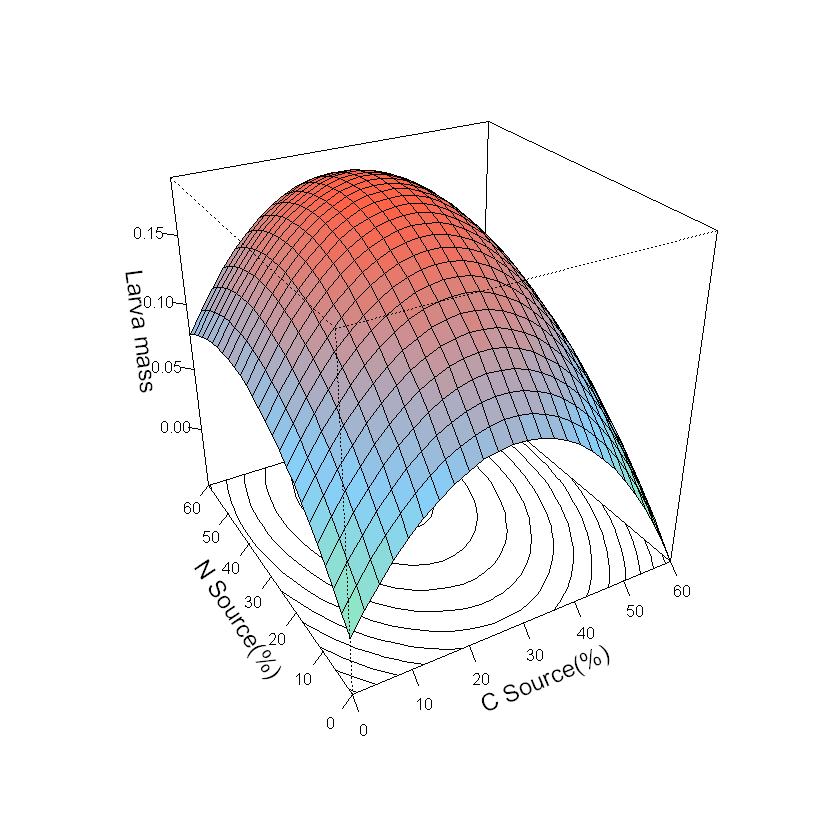

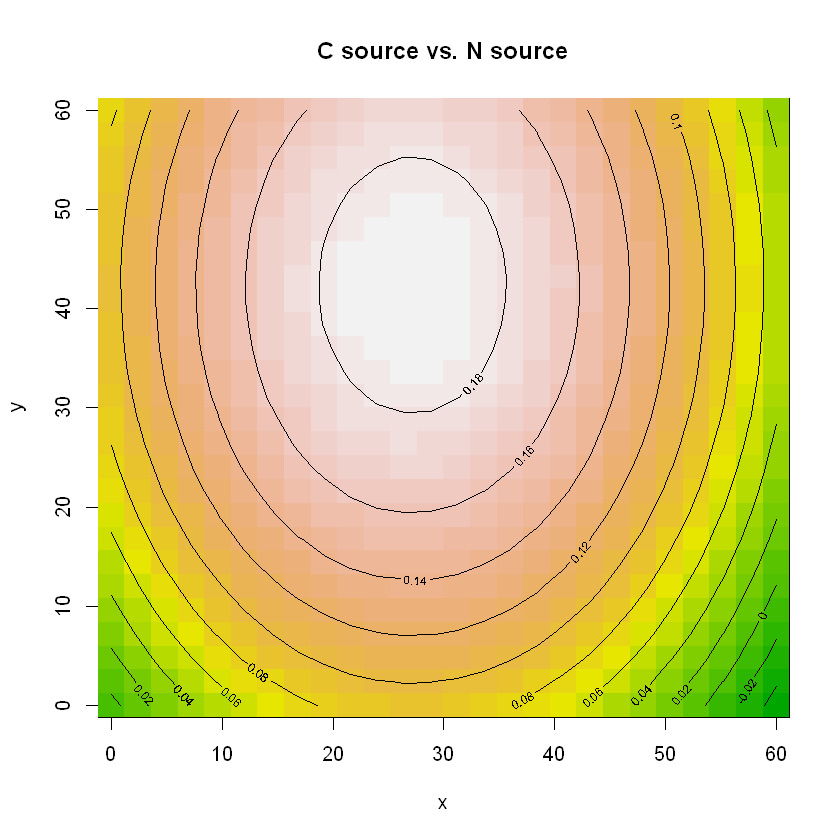

In [17]:
#####Response surface between non_fibre carbonhydrate and protein
###column x: non_fibre carbonhydrate (C)content; column y: protein (N) content; column; z: BSF weight gain (gram)
data<-read.csv("F://R_statistics_data/BSF_nutrition/C-N.csv")   
a2<-rsm(z ~ SO(x, y), data = data)
mycolors <- colorRampPalette(c("palegreen", "lightskyblue","tomato"))(30)
persp (a2, ~x+y, col = mycolors,phi=30,theta=-30,xlab=c("C Source(%)","N Source(%)"),zlab=c("Larva mass"),box = T,cex.lab=1.2, cex.axis=0.8,contour=list(z="bottom"))
summary(a2)
contour(a2, ~ x + y, image = TRUE, main="C source vs. N source")

Warning message in predict.lm(lmobj, newdata = newdata):
"prediction from a rank-deficient fit may be misleading"



Call:
rsm(formula = z ~ SO(x, y), data = data)

               Estimate  Std. Error t value  Pr(>|t|)    
(Intercept)  6.9690e-02  1.2049e-02  5.7837 7.750e-08 ***
x            7.1884e-03  8.8974e-04  8.0791 1.237e-12 ***
y            1.3609e-04  1.7446e-03  0.0780   0.93798    
x^2         -1.2327e-04  1.3786e-05 -8.9416 1.546e-14 ***
y^2         -1.1109e-04  5.3696e-05 -2.0689   0.04103 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Multiple R-squared:  0.5653,	Adjusted R-squared:  0.5486 
F-statistic: 33.81 on 4 and 104 DF,  p-value: < 2.2e-16

Analysis of Variance Table

Response: z
             Df   Sum Sq  Mean Sq F value    Pr(>F)
FO(x, y)      2 0.072564 0.036282  25.513 9.656e-10
PQ(x, y)      2 0.119766 0.059883  42.108 4.014e-14
Residuals   104 0.147901 0.001422                  
Lack of fit   4 0.105693 0.026423  62.603 < 2.2e-16
Pure error  100 0.042208 0.000422                  

Stationary point of response surface:
         x          y 
29.157

Warning message in predict.lm(lmobj, newdata = newdata):
"prediction from a rank-deficient fit may be misleading"


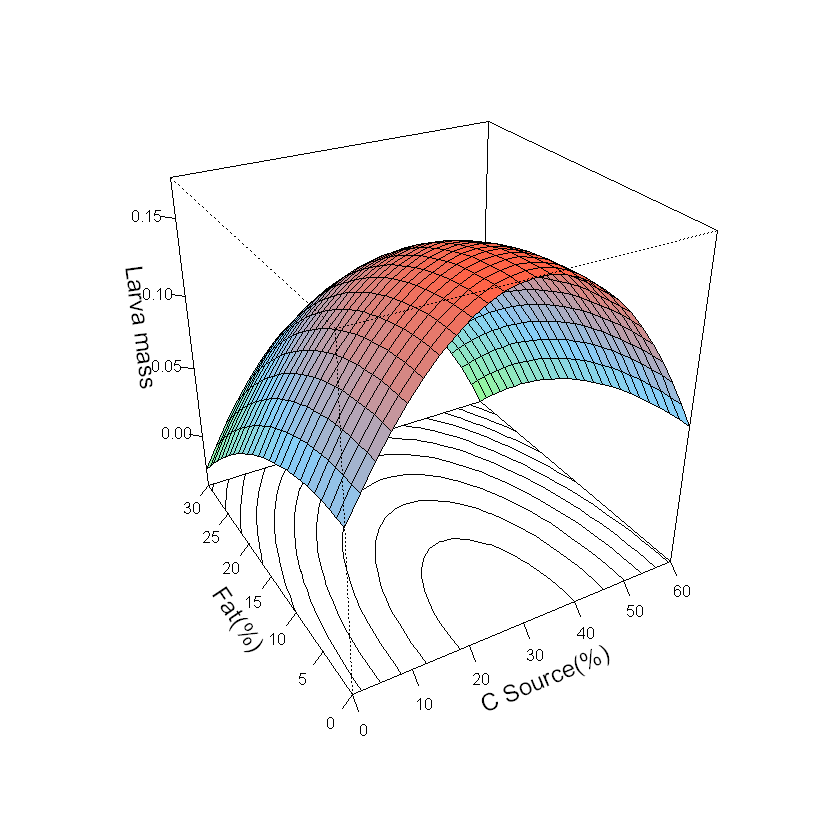

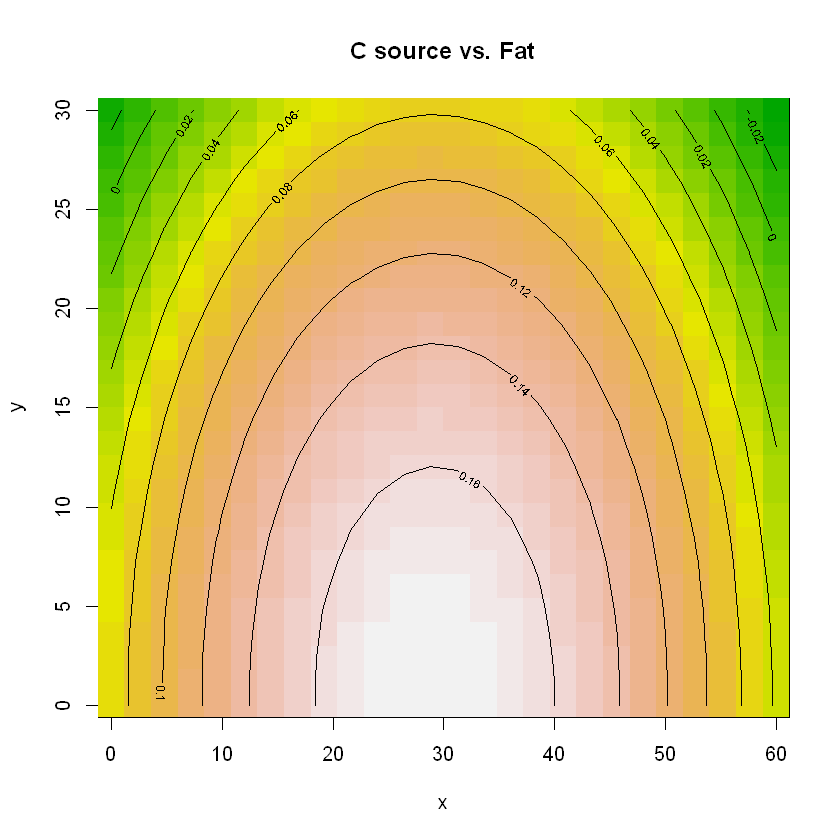

In [19]:
#####Response surface between non_fibre carbonhydrate and protein
###column x: non_carbonhydrate (C)content; column y: Fat content; column; z: BSF weight gain (gram)
data<-read.csv("F://R_statistics_data/BSF_nutrition/C-Fat.csv")   
a3<-rsm(z ~ SO(x, y), data = data)
mycolors <- colorRampPalette(c("palegreen", "lightskyblue","tomato"))(30)
persp (a3, ~x+y, col = mycolors,phi=30,theta=-30,xlab=c("C Source(%)","Fat(%)"),zlab=c("Larva mass"),box = T,cex.lab=1.2, cex.axis=0.8,contour=list(z="bottom"))
summary(a3)
contour(a3, ~ x + y, image = TRUE, main="C source vs. Fat")

In [ ]:
######################################
#########################  SHAP analysis of XGboost model
#####################################

In [20]:
model <- xgboost::xgb.load("d:\\增量预测\\xgboost_model.json")         ####load xgboost model generated from Python        
train_X<-read.csv("d://增量预测//train_X.csv")                    #####load Train data splited by Python
train_X_mat<- xgboost::xgb.DMatrix(data.matrix(train_X))

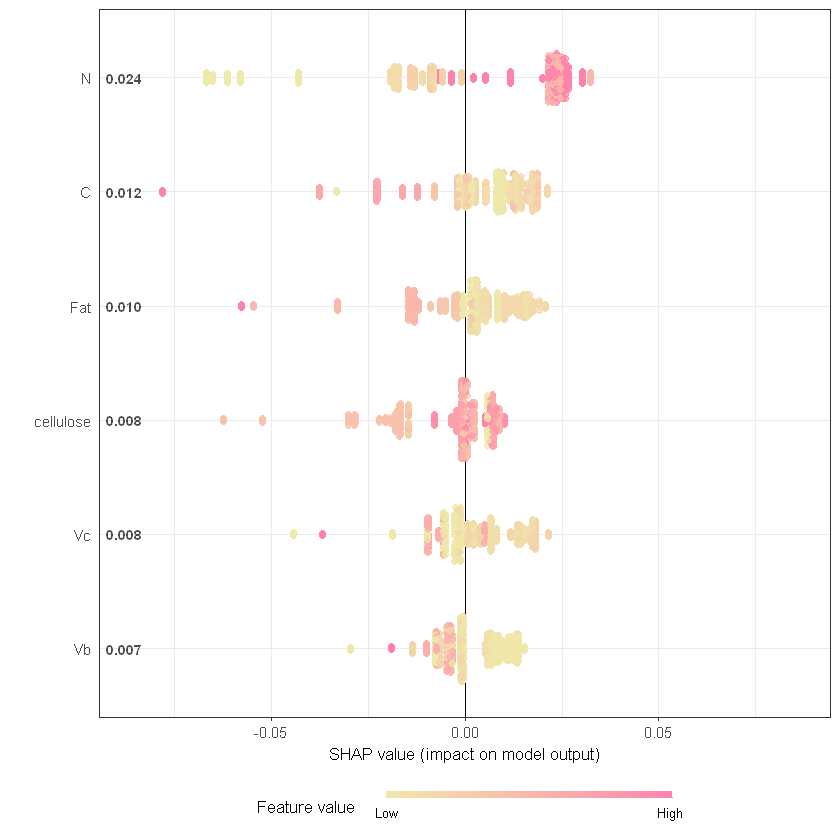

In [22]:
shap_values <- shap.values(xgb_model = model, X_train = train_X_mat)       ####calculate shap values
shap_long <- shap.prep(shap_contrib = shap_values$shap_score, X_train = as.matrix(train_X))
shap.plot.summary(shap_long,min_color_bound = "#EEE8AA", max_color_bound = "#FF82AB",kind = "sina")        #####visualize shap value of distinct features
#ggsave("d://增量预测//SHAP.eps", device=cairo_ps)

The SHAP values of the Rest 2 features were summed into variable 'rest_variables'.


Data has N = 828 | no zoom in.




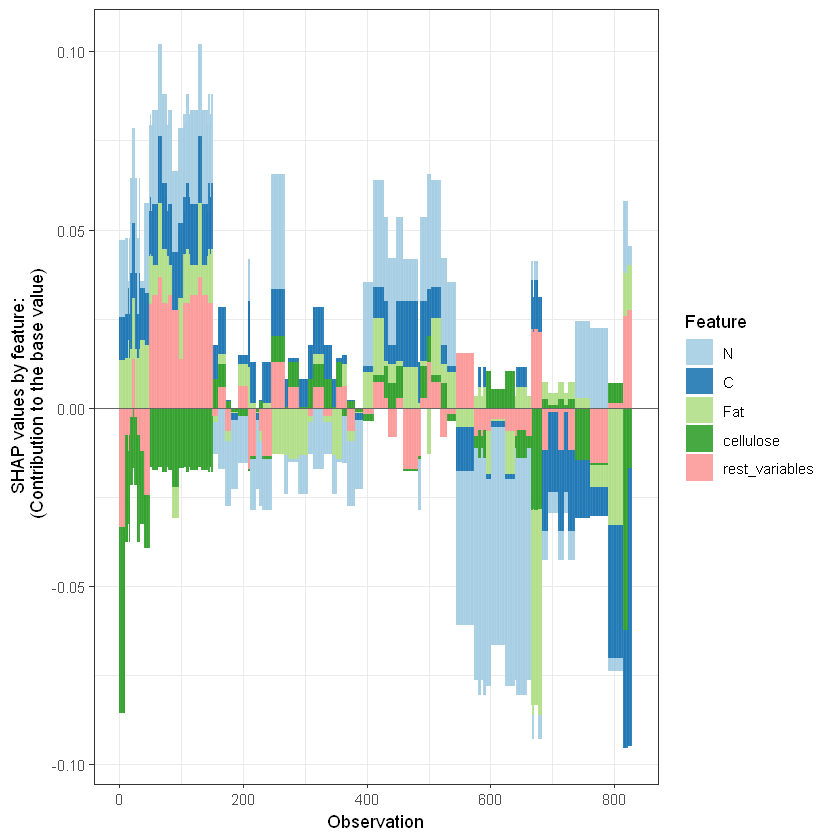

In [23]:
plot_data <- shap.prep.stack.data(shap_contrib = shap_values$shap_score, top_n = 4, n_groups = 6)        
shap.plot.force_plot(plot_data, zoom_in=FALSE)                                                            ####Generate SHAP interaction plot 
#ggsave("d://增量预测//SHAP-stack.eps", device=cairo_ps)

In [ ]:
write.csv(shap_long, "D://shap_long.csv")  ####output shap_long.csv to generate SHAP Dependance plot data, use column 'value' and 'rfvalue' for visualization.